I kinda wanted to visualize the geodesics and how the output changes, as they move through the latent space

In [ ]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from ensemble_vae import (
    VAE, GaussianPrior, GaussianDecoder, GaussianEncoder,
    PLcurve, pullback_metric, connecting_geodesic
)

M = 2 # latent dim

def new_encoder():
    encoder_net = nn.Sequential(
        nn.Conv2d(1, 16, 3, stride=2, padding=1),
        nn.Softmax(dim=1),
        nn.BatchNorm2d(16),
        nn.Conv2d(16, 32, 3, stride=2, padding=1),
        nn.Softmax(dim=1),
        nn.BatchNorm2d(32),
        nn.Conv2d(32, 32, 3, stride=2, padding=1),
        nn.Flatten(),
        nn.Linear(512, 2 * M),
    )
    return encoder_net

def new_decoder():
    decoder_net = nn.Sequential(
        nn.Linear(M, 512),
        nn.Unflatten(-1, (32, 4, 4)),
        nn.Softmax(dim=1),
        nn.BatchNorm2d(32),
        nn.ConvTranspose2d(32, 32, 3, stride=2, padding=1, output_padding=0),
        nn.Softmax(dim=1),
        nn.BatchNorm2d(32),
        nn.ConvTranspose2d(32, 16, 3, stride=2, padding=1, output_padding=1),
        nn.Softmax(dim=1),
        nn.BatchNorm2d(16),
        nn.ConvTranspose2d(16, 1, 3, stride=2, padding=1, output_padding=1),
    )
    return decoder_net

In [ ]:
def plot_morphing(model, z0, z1, num_t=20, title="Geodesic morphing"):
    """
    Plot a series of decoded images along the geodesic between z0 and z1,
    and also along the straight Euclidean line for comparison.
    """
    decoder_net = model.decoder.decoder_net
    metric = lambda z: pullback_metric(z, decoder_net)

    # Geodesic path
    curve = PLcurve(z0, z1, num_t)
    connecting_geodesic(metric, curve)
    geo_points = curve.points().detach()  # (num_t, 2)

    # Straight line path
    t = torch.linspace(0, 1, num_t).unsqueeze(1)
    straight_points = (1 - t) * z0 + t * z1  # (num_t, 2)

    # Decode all points
    with torch.no_grad():
        geo_imgs    = decoder_net(geo_points).cpu()       # (num_t, 1, 28, 28)
        straight_imgs = decoder_net(straight_points).cpu()

    fig, axes = plt.subplots(2, num_t, figsize=(num_t * 1.5, 3))
    for i in range(num_t):
        axes[0, i].imshow(geo_imgs[i, 0], cmap="gray", vmin=0, vmax=1)
        axes[0, i].axis("off")
        axes[1, i].imshow(straight_imgs[i, 0], cmap="gray", vmin=0, vmax=1)
        axes[1, i].axis("off")

    axes[0, 0].set_title("Geodesic", loc="left")
    axes[1, 0].set_title("Straight line", loc="left")
    plt.suptitle(title)
    plt.tight_layout()
    # plt.savefig("morphing.png", dpi=150)
    plt.show()

In [29]:
device = torch.device("cpu")
model = VAE(
    GaussianPrior(M),
    GaussianDecoder(new_decoder()),
    GaussianEncoder(new_encoder()),
).to(device)
model.load_state_dict(torch.load("experiment/model.pt", map_location=device))
model.eval()

VAE(
  (prior): GaussianPrior()
  (decoder): GaussianDecoder(
    (decoder_net): Sequential(
      (0): Linear(in_features=2, out_features=512, bias=True)
      (1): Unflatten(dim=-1, unflattened_size=(32, 4, 4))
      (2): Softmax(dim=1)
      (3): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (4): ConvTranspose2d(32, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (5): Softmax(dim=1)
      (6): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (7): ConvTranspose2d(32, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
      (8): Softmax(dim=1)
      (9): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (10): ConvTranspose2d(16, 1, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    )
  )
  (encoder): GaussianEncoder(
    (encoder_net): Sequential(
      (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(2, 2), p

In [30]:
# Encode some test data to get latent points
from torchvision import datasets, transforms
test_data = datasets.MNIST("data/", train=False, download=True,
    transform=transforms.ToTensor())
loader = torch.utils.data.DataLoader(test_data, batch_size=512)

all_z      = []
all_labels = []
with torch.no_grad():
    for x, y in loader:
        all_z.append(model.encoder(x).mean)
        all_labels.append(y)
all_z = torch.cat(all_z)
all_labels = torch.cat(all_labels)

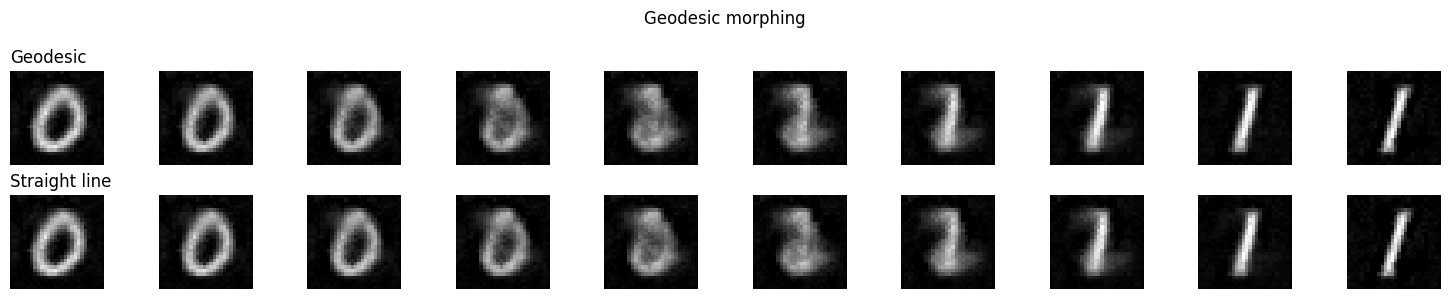

In [32]:
z0 = all_z[all_labels == 0][0].detach()
z1 = all_z[all_labels == 1][0].detach()
plot_morphing(model, z0, z1, num_t=10)

Looks like it reasonably morphs from one number to another.

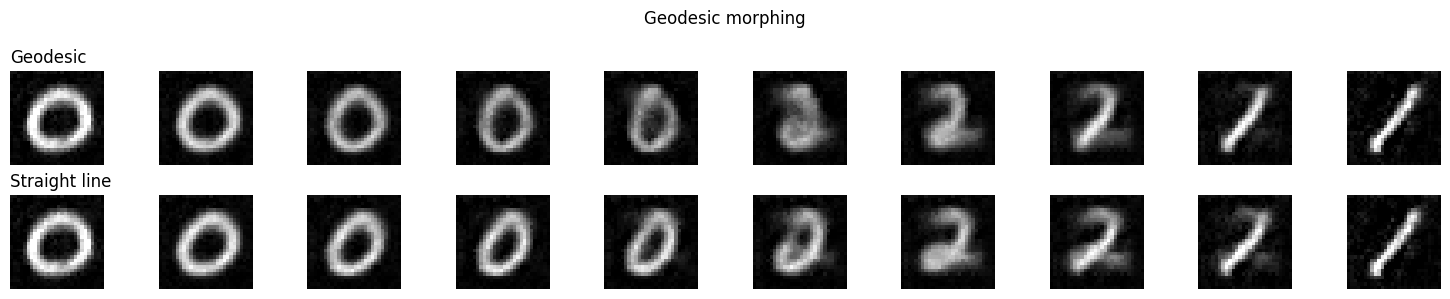

In [31]:
# Find a 0 and a 1 that are far apart in latent space
z0s = all_z[all_labels == 0]
z1s = all_z[all_labels == 1]

# Pick the ones with maximum distance between them
dists = torch.cdist(z0s, z1s)
i, j = torch.unravel_index(dists.argmax(), dists.shape)
z0 = z0s[i].detach()
z1 = z1s[j].detach()
plot_morphing(model, z0, z1, num_t=10)

Trying to find an more odd geodesic, a curve that went through '2' when going from '0' to '1' was found.
This experiment can be seen in the plot of the geodesics as well.